Membaca berkas JSONL dan mengekstrak komponen NER...
Ekstrak data NER selesai!

Menggambar Grafik EDA Proyek B...


C:\Users\PC\AppData\Local\Temp\ipykernel_31576\1915576908.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Entities_Count', data=df_review_metrics, ax=axes[0, 1], palette='muted')
C:\Users\PC\AppData\Local\Temp\ipykernel_31576\1915576908.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_series.values, y=label_series.index, ax=axes[1, 0], palette='magma')
C:\Users\PC\AppData\Local\Temp\ipykernel_31576\1915576908.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word_Count', y='Label', data=df_span_metrics, ax=axes[1,

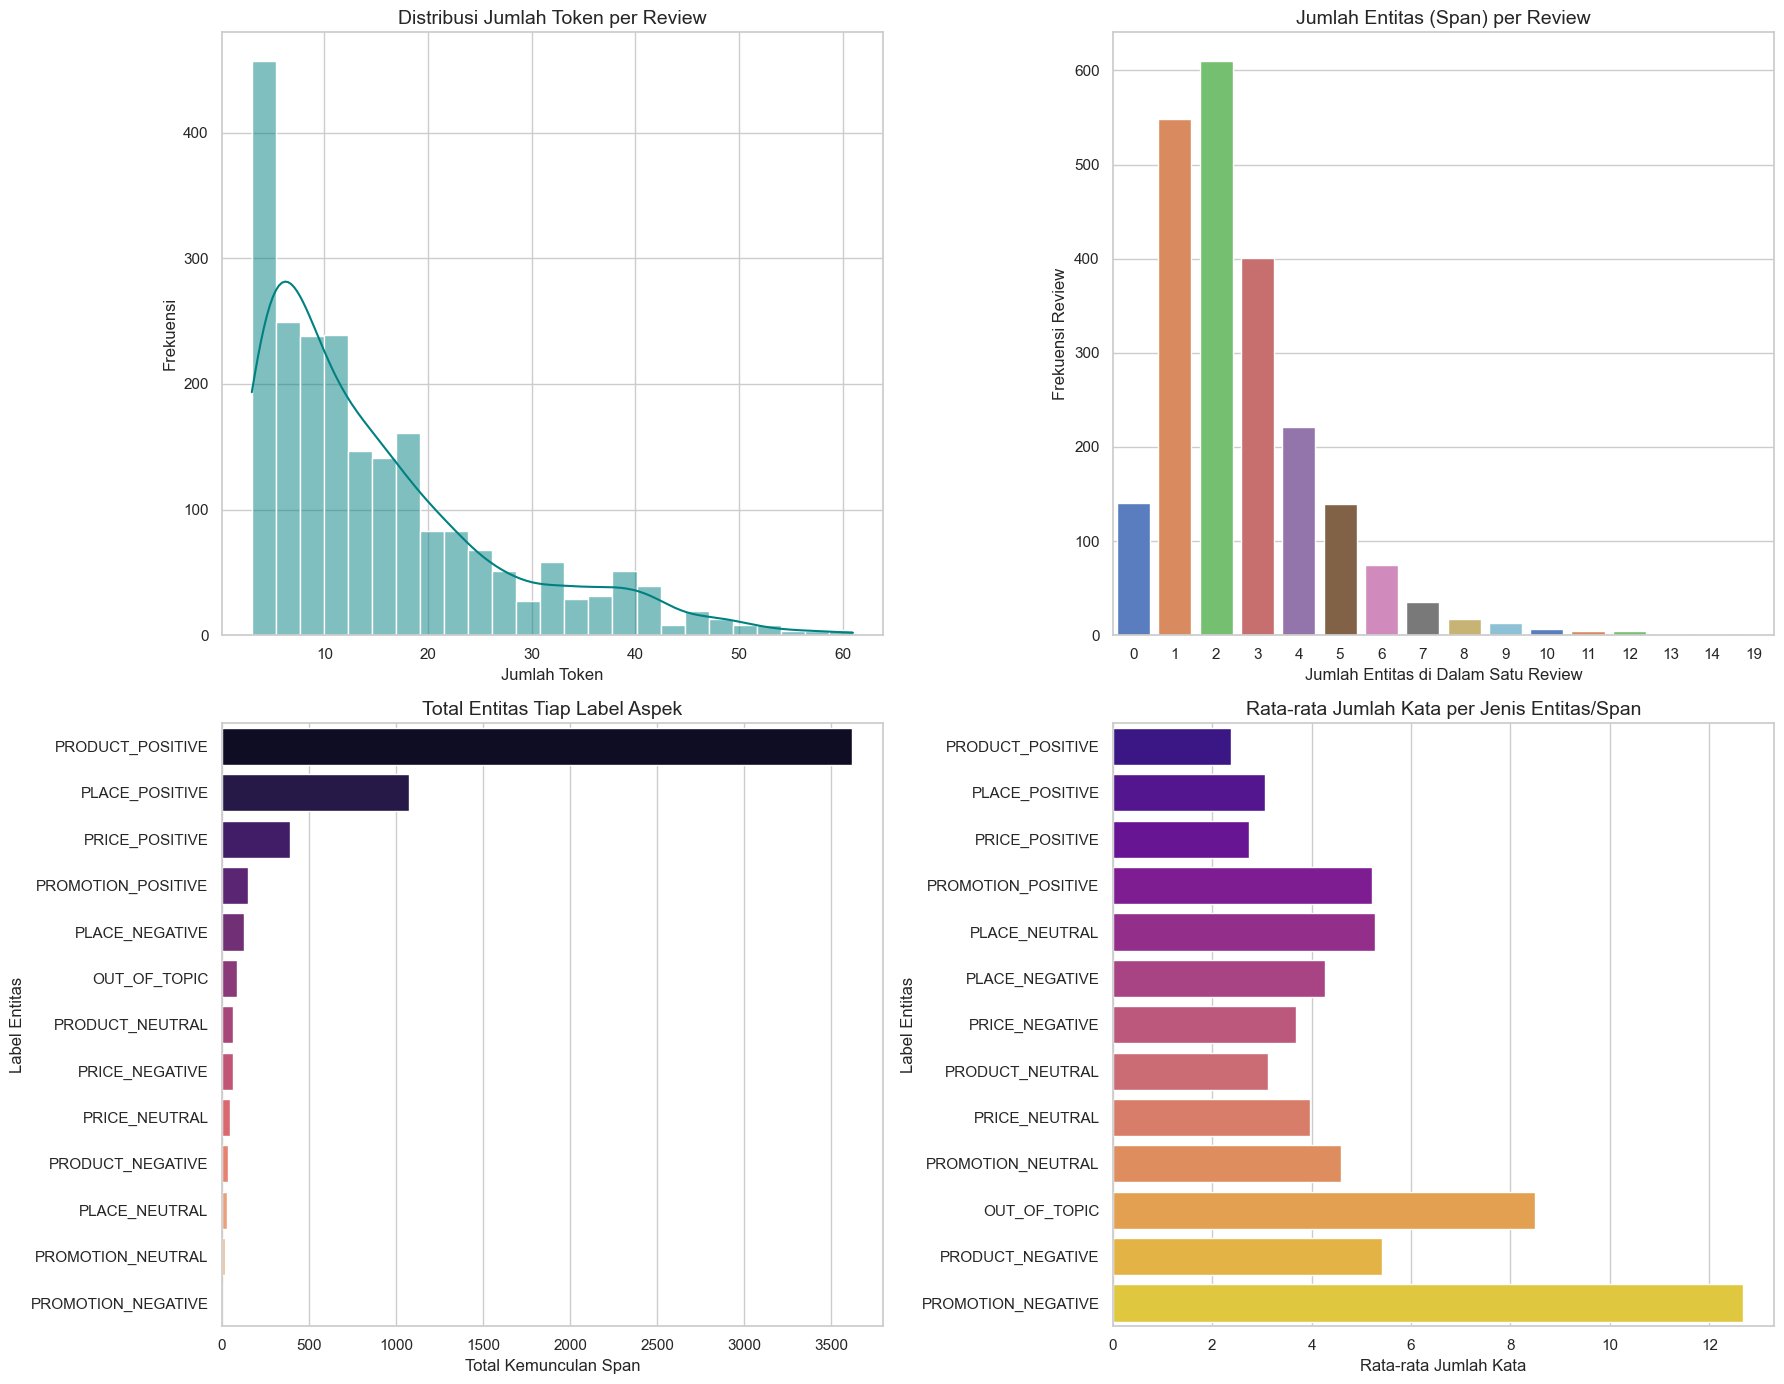

Selesai!


In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset_dir = '../dataset'
ner_train_path = os.path.join(dataset_dir, 'Kelp3_ner_train.jsonl')


tokens_per_review = []
entities_per_review = []
all_entity_labels = []
span_word_counts = []

print("Membaca berkas JSONL dan mengekstrak komponen NER...")

with open(ner_train_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        text = data.get('text', '')
        tokens = data.get('tokens', [])
        spans = data.get('spans', [])
        
        # 1. Hitung jumlah token per review
        tokens_per_review.append(len(tokens))
        
        # 2. Hitung jumlah entitas/span per review
        entities_per_review.append(len(spans))
        
        # 3. liat setiap entitas di dalam teks
        for span in spans:
            label = span.get('label', 'UNKNOWN')
            all_entity_labels.append(label)
            
            # Potong teks asli berdasarkan koordinat start & end span
            start_char = span.get('start', 0)
            end_char = span.get('end', 0)
            extracted_span_text = text[start_char:end_char]
            
            # Hitung berapa kata di dalam span tersebut
            word_count = len(extracted_span_text.split())
            span_word_counts.append({
                'Label': label,
                'Word_Count': word_count
            })

# Ubah ke DataFrame agar mudah digambar
df_review_metrics = pd.DataFrame({
    'Tokens_Count': tokens_per_review,
    'Entities_Count': entities_per_review
})
df_span_metrics = pd.DataFrame(span_word_counts)

print("Ekstrak data NER selesai!")

# PROSES MENGGAMBAR 4 GRAFIK EDA NER (TARGET NILAI 95)
print("\nMenggambar Grafik EDA Proyek B...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# GRAPH 1: Distribusi Jumlah Token per Review
sns.histplot(df_review_metrics['Tokens_Count'], bins=25, kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Distribusi Jumlah Token per Review', fontsize=14)
axes[0, 0].set_xlabel('Jumlah Token')
axes[0, 0].set_ylabel('Frekuensi')

# GRAPH 2: Jumlah Entitas per Review
# Menggunakan countplot karena jumlah entitas per review biasanya berupa angka bulat kecil
sns.countplot(x='Entities_Count', data=df_review_metrics, ax=axes[0, 1], palette='muted')
axes[0, 1].set_title('Jumlah Entitas (Span) per Review', fontsize=14)
axes[0, 1].set_xlabel('Jumlah Entitas di Dalam Satu Review')
axes[0, 1].set_ylabel('Frekuensi Review')

# GRAPH 3: Total Entitas Tiap Label (Distribusi Kelas NER)
label_series = pd.Series(all_entity_labels).value_counts()
sns.barplot(x=label_series.values, y=label_series.index, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Total Entitas Tiap Label Aspek', fontsize=14)
axes[1, 0].set_xlabel('Total Kemunculan Span')
axes[1, 0].set_ylabel('Label Entitas')

# GRAPH 4: Rata-rata Jumlah Kata/Token per Jenis Entitas
sns.barplot(x='Word_Count', y='Label', data=df_span_metrics, ax=axes[1, 1], palette='plasma', errorbar=None)
axes[1, 1].set_title('Rata-rata Jumlah Kata per Jenis Entitas/Span', fontsize=14)
axes[1, 1].set_xlabel('Rata-rata Jumlah Kata')
axes[1, 1].set_ylabel('Label Entitas')

plt.tight_layout()
plt.show()
print("Selesai!")

In [2]:
import os
import json
import pandas as pd

dataset_dir = '../dataset'

def convert_jsonl_to_bio(input_filename, output_filename):
    input_path = os.path.join(dataset_dir, input_filename)
    output_path = os.path.join(dataset_dir, output_filename)
    
    if not os.path.exists(input_path):
        print(f"File {input_filename} tidak ditemukan.")
        return
        
    bio_dataset = []
    
    with open(input_path, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            tokens = data.get('tokens', [])
            spans = data.get('spans', [])
            
            # membuat daftar tag 'O' awal sepanjang jumlah token
            tags = ['O'] * len(tokens)
            
            # mencocokkan setiap posisi token dengan koordinat karakter span
            for span in spans:
                span_start = span.get('start')
                span_end = span.get('end')
                # bersihkan nama label (ambil aspek utamanya saja, misal PRICE, PRODUCT, PLACE, PROMOTION)
                raw_label = span.get('label', 'UNKNOWN').split('_')[0] 
                
                is_first = True
                for idx, token in enumerate(tokens):
                    t_start = token.get('start')
                    t_end = token.get('end')
                    
                    # Cek apakah token berada di dalam jangkauan karakter span
                    if t_start >= span_start and t_end <= span_end:
                        if is_first:
                            tags[idx] = f"B-{raw_label}"
                            is_first = False
                        else:
                            # Jika token sebelumnya sudah B- atau I-, teruskan sebagai Inside (I-)
                            tags[idx] = f"I-{raw_label}"
            
            # Simpan kata dan tag bionya ke dalam list
            words = [t.get('text') for t in tokens]
            bio_dataset.append({
                'sentence_tokens': words,
                'bio_tags': tags
            })
            
    # Simpan hasil konversi ke file JSON baru untuk persiapan masuk ke model deep learning
    with open(output_path, 'w', encoding='utf-8') as out_f:
        json.dump(bio_dataset, out_f, ensure_ascii=False, indent=2)
        
    print(f"Berhasil mengonversi {input_filename} -> {output_filename}")
    return bio_dataset

print("Memulai proses pembuatan Tag BIO untuk data Train, Val, dan Test...")
# menjalankan konversi untuk ketiga pecahan data secara konsisten
train_bio = convert_jsonl_to_bio('Kelp3_ner_train.jsonl', 'Kelp3_bio_train.json')
val_bio = convert_jsonl_to_bio('Kelp3_ner_val.jsonl', 'Kelp3_bio_val.json')
test_bio = convert_jsonl_to_bio('Kelp3_ner_test.jsonl', 'Kelp3_bio_test.json')

# liat contoh hasil konversi baris pertama data Train
print("\nContoh Hasil Konversi Baris Pertama (Token & Tag BIO):")
if train_bio:
    example = train_bio[1] # liat baris kedua biar lebih kelihatan aspeknya
    for w, t in zip(example['sentence_tokens'][:15], example['bio_tags'][:15]):
        print(f"{w:<15} -> {t}")

Memulai proses pembuatan Tag BIO untuk data Train, Val, dan Test...
Berhasil mengonversi Kelp3_ner_train.jsonl -> Kelp3_bio_train.json
Berhasil mengonversi Kelp3_ner_val.jsonl -> Kelp3_bio_val.json
Berhasil mengonversi Kelp3_ner_test.jsonl -> Kelp3_bio_test.json

Contoh Hasil Konversi Baris Pertama (Token & Tag BIO):
Pas             -> B-PLACE
buat            -> I-PLACE
emak            -> I-PLACE
emak            -> I-PLACE
yg              -> I-PLACE
suka            -> I-PLACE
shopping        -> I-PLACE
...             -> O


In [6]:
import os
import json
import torch
import numpy as np
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification
from evaluate import load

# 1. KONFIGURASI PATH & SKEMA LABEL MINIMAL
dataset_dir = '../dataset'
model_checkpoint = "indobenchmark/indobert-base-p1"

# Skema tag NER minimal
label_list = ['O', 'B-PRODUCT', 'I-PRODUCT', 'B-PRICE', 'I-PRICE', 'B-PLACE', 'I-PLACE', 'B-PROMOTION', 'I-PROMOTION']
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for i, l in enumerate(label_list)}

print("Loading Tokenizer IndoBERT...")
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, do_lower_case=True)

# 2. FUNGSI LOAD DATA BIO JSON
def load_bio_json(filename):
    with open(os.path.join(dataset_dir, filename), 'r', encoding='utf-8') as f:
        return json.load(f)

train_data = load_bio_json('Kelp3_bio_train.json')
val_data = load_bio_json('Kelp3_bio_val.json')

# 3. PROSES ALIGNMENT TOKEN-LABEL (SUBWORD HANDLING)
def align_and_tokenize(data_list):
    tokenized_inputs = []
    
    for item in data_list:
        words = item['sentence_tokens']
        labels = item['bio_tags']
        
        # Tokenisasi menggunakan tokenizer bawaan IndoBERT
        inputs = tokenizer(words, is_split_into_words=True, truncation=True, max_length=128)
        
        # Mapping token hasil potongan subwords kembali ke ID label asli
        word_ids = inputs.word_ids()
        label_ids = []
        
        for word_idx in word_ids:
            if word_idx is None:
                # tag -100 untuk token spesial ([CLS], [SEP]) agar diabaikan oleh fungsi loss PyTorch
                label_ids.append(-100)
            else:
                label_name = labels[word_idx]
                # Jika tag tidak terdaftar di skema minimal, amankan sebagai 'O'
                label_ids.append(label2id.get(label_name, 0))
                
        inputs["labels"] = label_ids
        tokenized_inputs.append(inputs)
        
    return tokenized_inputs

print("Menyelaraskan token subword IndoBERT dengan label tag BIO...")
train_tokenized = align_and_tokenize(train_data)
val_tokenized = align_and_tokenize(val_data)

# 4. MEMBUAT PYTORCH DATASET CLASS
class NERDataset(Dataset):
    def __init__(self, tokenized_data):
        self.data = tokenized_data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return {k: torch.tensor(v) for k, v in self.data[idx].items()}

train_dataset = NERDataset(train_tokenized)
val_dataset = NERDataset(val_tokenized)

# 5. SETUP METRIK EVALUASI (SEQEVAL)
metric = load("seqeval")
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

# 6. KONFIGURASI ARSITEKTUR INDOBERT TOKEN CLASSIFICATION
print("Mengunduh & Mengonfigurasi Arsitektur IndoBERT di GPU...")
model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint, 
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

# 7. CONFIG TRAINING ARGUMENTS (DENGAN EARLY STOPPING/TUNING)
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16, 
    per_device_eval_batch_size=16,
    num_train_epochs=5,             # Latih sebanyak 5 iterasi penuh
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,     # Otomatis mengunci model terbaik di akhir epoch (Tuning)
    metric_for_best_model="f1",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=compute_metrics
)

print("\nMemulai Proses Pelatihan Model NER IndoBERT...")
trainer.train()
print("Pelatihan Selesai! Model terbaik telah disimpan otomatis.")

Loading Tokenizer IndoBERT...
Menyelaraskan token subword IndoBERT dengan label tag BIO...
Mengunduh & Mengonfigurasi Arsitektur IndoBERT di GPU...


[transformers] You passed `num_labels=9` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



Memulai Proses Pelatihan Model NER IndoBERT...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Pelatihan Selesai! Model terbaik telah disimpan otomatis.


In [8]:
from seqeval.metrics import classification_report as seqeval_report

print("Memproses dan menyelaraskan data Test Set...")
# 1. Load dan tokenisasi data test
test_data = load_bio_json('Kelp3_bio_test.json')
test_tokenized = align_and_tokenize(test_data)
test_dataset = NERDataset(test_tokenized)

print("Melakukan prediksi model terbaik pada Test Set...")
# 2. Ambil hasil prediksi dari trainer
predictions, labels, _ = trainer.predict(test_dataset)
predictions = np.argmax(predictions, axis=2)

# 3. Konversi ID angka kembali menjadi teks Tag BIO (abaikan tag -100)
true_predictions = [
    [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]
true_labels = [
    [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

print("\n========================================================")
print("CLASSIFICATION REPORT PER ENTITAS (PROYEK B - NER)")
print("========================================================")
# Menggunakan seqeval_report untuk mengevaluasi performa kelompok frasa entitas secara utuh
print(seqeval_report(true_labels, true_predictions, zero_division=0))


# 4. KODE ANALISIS KESALAHAN (ERROR ANALYSIS NER)
print("\nMEMULAI ANALISIS KESALAHAN MODEL NER (CONTOH KASUS SALAH TAG):")
print("====================================================================")

error_count = 0
for idx in range(len(test_data)):
    if error_count >= 2: # tampilkan 2 contoh kasus saja agar ringkas
        break
        
    t_label = true_labels[idx]
    p_label = true_predictions[idx]
    
    # Jika ada perbedaan tebakan tag di dalam kalimat
    if t_label != p_label:
        words = test_data[idx]['sentence_tokens']
        print(f"\n❌ Contoh Salah {error_count+1}:")
        print(f"{'Kata':<12} | {'Label Asli':<12} | {'AI Menebak':<12} | Status")
        print("-" * 55)
        
        # Menggabungkan token kata, label asli, dan hasil prediksi secara aman
        for w, tl, pl in list(zip(words, t_label, p_label))[:12]:
            status = "✅" if tl == pl else "❌"
            print(f"{w:<12} | {tl:<12} | {pl:<12} | {status}")
            
        print("-" * 55)
        error_count += 1

Memproses dan menyelaraskan data Test Set...
Melakukan prediksi model terbaik pada Test Set...



CLASSIFICATION REPORT PER ENTITAS (PROYEK B - NER)
              precision    recall  f1-score   support

       PLACE       0.33      0.39      0.36       332
       PRICE       0.52      0.54      0.53       122
     PRODUCT       0.47      0.53      0.50      1101
   PROMOTION       0.00      0.00      0.00        42

   micro avg       0.43      0.49      0.46      1597
   macro avg       0.33      0.36      0.34      1597
weighted avg       0.43      0.49      0.46      1597


MEMULAI ANALISIS KESALAHAN MODEL NER (CONTOH KASUS SALAH TAG):

❌ Contoh Salah 1:
Kata         | Label Asli   | AI Menebak   | Status
-------------------------------------------------------
Sangat       | B-PRODUCT    | B-PLACE      | ❌
bagus        | I-PRODUCT    | I-PLACE      | ❌
dan          | O            | O            | ✅
Rama         | B-PLACE      | B-PLACE      | ✅
...          | O            | O            | ✅
-------------------------------------------------------

❌ Contoh Salah 2:
Kata        

In [9]:
import os


ner_model_dir = '../models/Kelp3_best_indobert_ner'
os.makedirs(ner_model_dir, exist_ok=True)

print("Menyimpan Model IndoBERT NER dan Tokenizer ke folder models...")
# Simpan weights model dan konfigurasi tokenizer secara permanen
trainer.save_model(ner_model_dir)
tokenizer.save_pretrained(ner_model_dir)

print("Model dan Tokenizer berhasil disimpan di folder:", ner_model_dir)

Menyimpan Model IndoBERT NER dan Tokenizer ke folder models...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model dan Tokenizer berhasil disimpan di folder: ../models/Kelp3_best_indobert_ner
